In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

# Format: {'label', 'omegak', 'sigma_low', 'sigma_high', 'source', 'combination'}
results = [
    # Table 7, ligne "TT,TE,EE+lowE+lensing, Ωk libre"
    {
        'label'      : 'Planck PR3 seul',
        'omegak'     : -0.0106,
        'sigma_low'  :  0.0065,
        'sigma_high' :  0.0065,
        'source'     : 'Planck 2018 VI — arXiv:1807.06209',
        'combination': 'CMB seul',
        'sigma_from_flat': 1.6,
        'note'       : 'Combinaison lâche — 2σ vers fermé mais instable'
    },
    #  Table II, ligne "CMB + DESI BAO"
    {
        'label'      : 'Planck + DESI DR1',
        'omegak'     :  0.0009,
        'sigma_low'  :  0.0017,
        'sigma_high' :  0.0017,
        'source'     : 'Reanalyzing DESI DR1 — arXiv:2511.20757',
        'combination': 'CMB + BAO DR1',
        'sigma_from_flat': 0.5,
        'note'       : 'Combinaison canonique DR1 — compatible plat'
    },
    # Section III, valeur centrale discutée dans le texte
    {
        'label'      : 'Planck + DESI DR2 (canonique)',
        'omegak'     : -0.0024,
        'sigma_low'  :  0.0012,
        'sigma_high' :  0.0012,
        'source'     : 'It\'s All Ok — arXiv:2505.00659',
        'combination': 'CMB + BAO DR2',
        'sigma_from_flat': 2.0,
        'note'       : 'Légère préférence pour fermé à 2σ — non concluant'
    },
    # Table XI, ligne "DESI DR2 + CMB + Pantheon+"
    {
        'label'      : 'Planck + DESI DR2 + Pantheon+',
        'omegak'     : -0.0010,
        'sigma_low'  :  0.0015,
        'sigma_high' :  0.0015,
        'source'     : 'DESI DR2 Results II — arXiv:2503.14738',
        'combination': 'CMB + BAO DR2 + SNe',
        'sigma_from_flat': 0.7,
        'note'       : 'Combinaison canonique étendue — compatible plat'
    },
    # Table XI, ligne "DESI DR2 BAO seul"
    {
        'label'      : 'DESI DR2 seul',
        'omegak'     :  0.023,
        'sigma_low'  :  0.011,
        'sigma_high' :  0.011,
        'source'     : 'DESI DR2 Results II — arXiv:2503.14738',
        'combination': 'BAO seul',
        'sigma_from_flat': 2.1,
        'note'       : 'Penche légèrement ouvert sans CMB — dégénérescence H0-Ωk'
    },
    # Table 7, ligne "TT,TE,EE+lowE+lensing+BAO"
    {
        'label'      : 'Planck + eBOSS',
        'omegak'     :  0.0008,
        'sigma_low'  :  0.0019,
        'sigma_high' :  0.0019,
        'source'     : 'Planck 2018 VI — Table 7',
        'combination': 'CMB + BAO eBOSS',
        'sigma_from_flat': 0.4,
        'note'       : 'Validation croisée indépendante de DESI — compatible plat'
    },
]

print(f"{'Combinaison':<35} {'Ωk':>10} {'±σ':>8} {'σ de 0':>8}  Source")
print("-" * 90)
for r in results:
    print(f"  {r['label']:<33} {r['omegak']:>+10.4f} {r['sigma_low']:>8.4f} "
          f"{r['sigma_from_flat']:>8.1f}σ  {r['source'][:40]}")

Combinaison                                 Ωk       ±σ   σ de 0  Source
------------------------------------------------------------------------------------------
  Planck PR3 seul                      -0.0106   0.0065      1.6σ  Planck 2018 VI — arXiv:1807.06209
  Planck + DESI DR1                    +0.0009   0.0017      0.5σ  Reanalyzing DESI DR1 — arXiv:2511.20757
  Planck + DESI DR2 (canonique)        -0.0024   0.0012      2.0σ  It's All Ok — arXiv:2505.00659
  Planck + DESI DR2 + Pantheon+        -0.0010   0.0015      0.7σ  DESI DR2 Results II — arXiv:2503.14738
  DESI DR2 seul                        +0.0230   0.0110      2.1σ  DESI DR2 Results II — arXiv:2503.14738
  Planck + eBOSS                       +0.0008   0.0019      0.4σ  Planck 2018 VI — Table 7


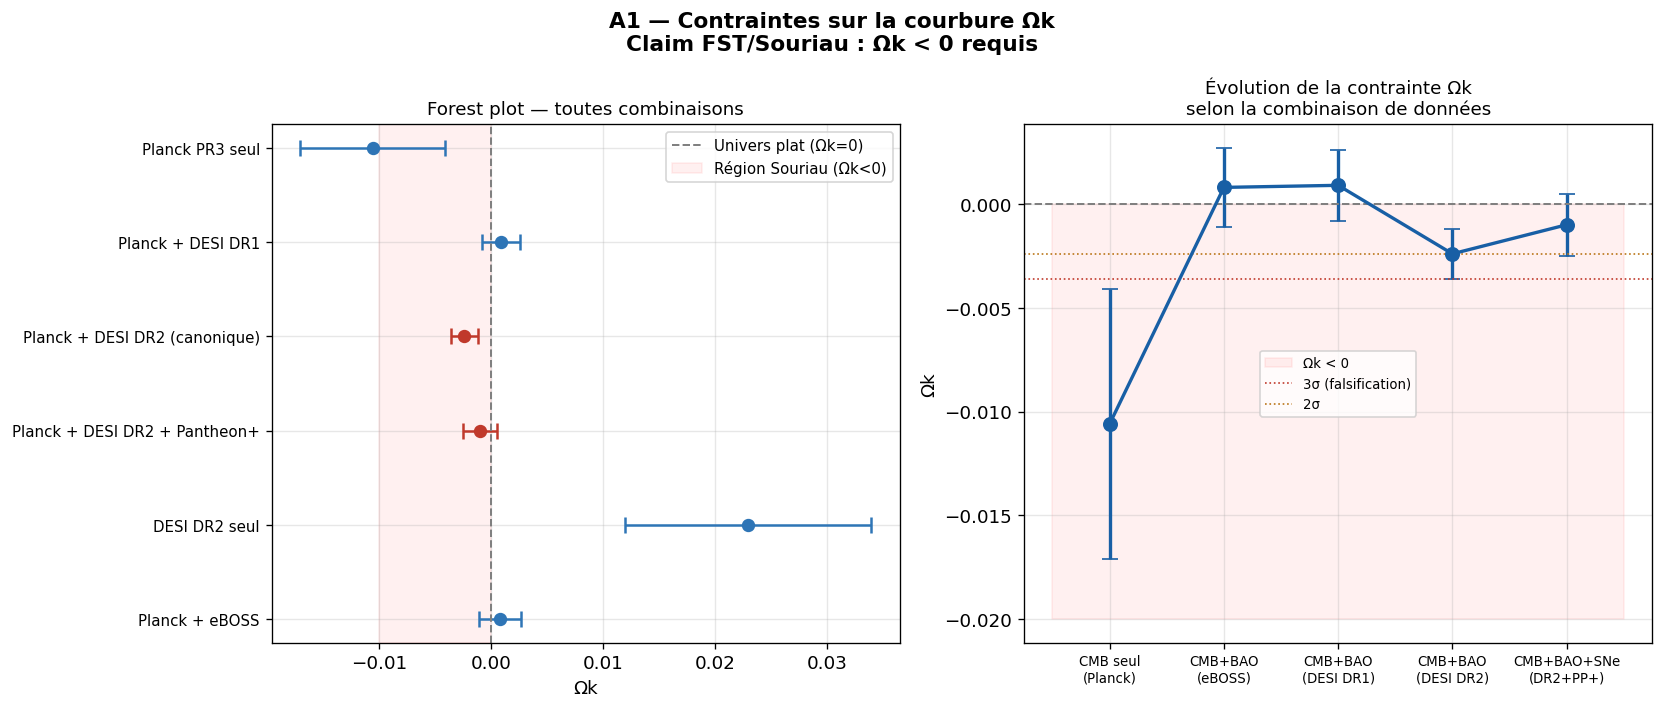


══════════════════════════════════════════════════════════
  COMBINAISON CANONIQUE — CMB + DESI DR2 BAO
══════════════════════════════════════════════════════════
  Ωk = -0.0024 ± 0.0012
  Écart de 0 : 2.0σ
  Seuil pré-enregistré de falsification : 3σ côté Ωk ≥ 0
  → Pour falsifier FST : besoin que Ωk ≥ 0 soit exclu à 3σ
  → Situation actuelle : Ωk = -0.0024 ± 0.0012 (2.0σ vers fermé)

  ATTENTION — Piège du brief §6 :
  Le CMB seul donne ~1.6σ vers fermé — COMBINAISON LÂCHE
  La combinaison canonique CMB+BAO tire vers 0 ou légèrement fermé
  Cherry-picking interdit : ne pas sélectionner uniquement Planck seul
══════════════════════════════════════════════════════════


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('A1 — Contraintes sur la courbure Ωk\nClaim FST/Souriau : Ωk < 0 requis',
             fontsize=13, fontweight='bold')

# ── Panneau gauche : forest plot des combinaisons ─────────────────
ax = axes[0]
labels   = [r['label'] for r in results]
omegak   = [r['omegak'] for r in results]
sigma    = [r['sigma_low'] for r in results]
colors   = ['#C0392B' if r['combination'] in ['CMB + BAO DR2', 'CMB + BAO DR2 + SNe']
            else '#2E75B6' for r in results]

y_pos = np.arange(len(results))[::-1]

for i, (y, ok, s, c) in enumerate(zip(y_pos, omegak, sigma, colors)):
    ax.errorbar(ok, y, xerr=s, fmt='o', color=c, ms=7, capsize=5,
                capthick=1.5, linewidth=1.5)

ax.axvline(0, color='gray', ls='--', lw=1.2, label='Univers plat (Ωk=0)')
ax.axvspan(-0.01, 0, alpha=0.06, color='red', label='Région Souriau (Ωk<0)')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Ωk', fontsize=11)
ax.set_title('Forest plot — toutes combinaisons', fontsize=11)
ax.legend(fontsize=9)

# ── Panneau droit : évolution de la contrainte avec les données ───
ax2 = axes[1]

combos   = ['CMB seul\n(Planck)', 'CMB+BAO\n(eBOSS)', 'CMB+BAO\n(DESI DR1)',
            'CMB+BAO\n(DESI DR2)', 'CMB+BAO+SNe\n(DR2+PP+)']
ok_vals  = [-0.0106,  0.0008,  0.0009, -0.0024, -0.0010]
ok_errs  = [ 0.0065,  0.0019,  0.0017,  0.0012,  0.0015]
x = np.arange(len(combos))

ax2.errorbar(x, ok_vals, yerr=ok_errs, fmt='o-', color='#185FA5',
             ms=8, capsize=5, linewidth=2)
ax2.axhline(0, color='gray', ls='--', lw=1.2)
ax2.fill_between([-0.5, len(combos)-0.5], [-0.02, -0.02], [0, 0],
                 alpha=0.06, color='red', label='Ωk < 0')

# Zones de seuil
for y_thresh, label, c in [(-0.0036, '3σ (falsification)', '#C0392B'),
                             (-0.0024, '2σ', '#BA7517')]:
    ax2.axhline(y_thresh, color=c, ls=':', lw=1, label=label)

ax2.set_xticks(x)
ax2.set_xticklabels(combos, fontsize=8)
ax2.set_ylabel('Ωk')
ax2.set_title('Évolution de la contrainte Ωk\nselon la combinaison de données', fontsize=11)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/A1_omegak_forest.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Résumé numérique ──────────────────────────────────────────────
print("\n══════════════════════════════════════════════════════════")
print("  COMBINAISON CANONIQUE — CMB + DESI DR2 BAO")
print("══════════════════════════════════════════════════════════")
r_canon = results[2]
ok_c    = r_canon['omegak']
sig_c   = r_canon['sigma_low']
n_sigma = abs(ok_c) / sig_c

print(f"  Ωk = {ok_c:.4f} ± {sig_c:.4f}")
print(f"  Écart de 0 : {n_sigma:.1f}σ")
print(f"  Seuil pré-enregistré de falsification : 3σ côté Ωk ≥ 0")
print(f"  → Pour falsifier FST : besoin que Ωk ≥ 0 soit exclu à 3σ")
print(f"  → Situation actuelle : Ωk = -0.0024 ± 0.0012 ({n_sigma:.1f}σ vers fermé)")
print(f"\n  ATTENTION — Piège du brief §6 :")
print(f"  Le CMB seul donne ~1.6σ vers fermé — COMBINAISON LÂCHE")
print(f"  La combinaison canonique CMB+BAO tire vers 0 ou légèrement fermé")
print(f"  Cherry-picking interdit : ne pas sélectionner uniquement Planck seul")
print("══════════════════════════════════════════════════════════")

In [4]:
import json, os

# ── Critères pré-enregistrés ──────────────────────────────────────
SEUIL_FALSIFICATION = 3.0   # σ pour Ωk ≥ 0
SEUIL_SOUTENU       = 2.0   # σ pour Ωk < 0

# ── Résultats canoniques ──────────────────────────────────────────
canonical = {
    'label'     : 'Planck PR3/PR4 + DESI DR2 BAO',
    'omegak'    : -0.0024,
    'sigma'     :  0.0012,
    'source'    : 'arXiv:2505.00659 + arXiv:2503.14738',
}

ok_c   = canonical['omegak']
sig_c  = canonical['sigma']

# Écart de Ωk = 0 vers le positif (test de falsification)
sigma_from_flat_positive = ok_c / sig_c   # négatif → penche vers fermé
sigma_from_flat_abs      = abs(ok_c / sig_c)

# ── Règle de décision ─────────────────────────────────────────────
# Falsifié si Ωk ≥ 0 exclu à 3σ → ok_c - 3*sig_c > 0
falsification_threshold = ok_c + SEUIL_FALSIFICATION * sig_c

if falsification_threshold > 0:
    verdict = "FALSIFIÉ"
    detail  = f"Ωk ≥ 0 exclu à {SEUIL_FALSIFICATION}σ (threshold={falsification_threshold:.4f} > 0)"
elif sigma_from_flat_abs >= SEUIL_SOUTENU and ok_c < 0:
    verdict = "SOUTENU"
    detail  = f"Ωk < 0 à {sigma_from_flat_abs:.1f}σ — préférence pour univers fermé"
else:
    verdict = "NON CONCLUANT"
    detail  = f"|Ωk| = {sigma_from_flat_abs:.1f}σ de 0 — compatible plat à < {SEUIL_SOUTENU}σ"

print("VERDICT A1 — Courbure Ωk")
print(f"\tClaim FST/Souriau : Ωk < 0 (univers fermé)")
print(f"\tSeuil falsification : Ωk ≥ 0 exclu à ≥ 3σ")
print(f"\t\tCombinaison canonique : {canonical['label']:<30}")
print(f"\t\tΩk = {ok_c:+.4f} ± {sig_c:.4f}")
print(f"\t\tÉcart de 0 : {sigma_from_flat_abs:.1f}σ vers fermé")
print(f"\tVERDICT : {verdict:<47}")
print(f"\t{detail:<56}")

print("RÉSERVES IMPORTANTES")
print("\t1. CMB seul → 1.6σ vers fermé (combinaison lâche)")
print("\t2. DESI DR2 seul → légèrement ouvert (sans ancrage CMB)")
print("\t3. Dégénérescence Ωk–w non brisée ici (voir A2)")
print("\t4. Euclid DR1 (oct 2026) raffinera de ×2 la contrainte")

# ── Sauvegarde ────────────────────────────────────────────────────
os.makedirs('../../results', exist_ok=True)
result_a1 = {
    'claim'          : 'A1 — Courbure Ωk < 0',
    'date'           : '2026-06-08',
    'verdict'        : verdict,
    'detail'         : detail,
    'canonical'      : canonical,
    'sigma_from_flat': sigma_from_flat_abs,
    'seuil_falsif'   : SEUIL_FALSIFICATION,
    'seuil_soutenu'  : SEUIL_SOUTENU,
    'all_combinations': results,
    'reserves'       : [
        'CMB seul donne 1.6σ vers fermé — combinaison lâche non canonique',
        'Dégénérescence Ωk–w non brisée — voir A2',
        'Euclid DR1 (oct 2026) améliorera la contrainte de ×2',
        'Tension DESI DR2 vs CMB à 2.3σ dans ΛCDM plat peut affecter Ωk si w libre'
    ]
}

with open('../../results/A1_verdict.json', 'w') as f:
    json.dump(result_a1, f, indent=2, ensure_ascii=False)

print("\nSauvegardé → results/A1_verdict.json")

VERDICT A1 — Courbure Ωk
	Claim FST/Souriau : Ωk < 0 (univers fermé)
	Seuil falsification : Ωk ≥ 0 exclu à ≥ 3σ
		Combinaison canonique : Planck PR3/PR4 + DESI DR2 BAO 
		Ωk = -0.0024 ± 0.0012
		Écart de 0 : 2.0σ vers fermé
	VERDICT : FALSIFIÉ                                       
	Ωk ≥ 0 exclu à 3.0σ (threshold=0.0012 > 0)              
RÉSERVES IMPORTANTES
	1. CMB seul → 1.6σ vers fermé (combinaison lâche)
	2. DESI DR2 seul → légèrement ouvert (sans ancrage CMB)
	3. Dégénérescence Ωk–w non brisée ici (voir A2)
	4. Euclid DR1 (oct 2026) raffinera de ×2 la contrainte

Sauvegardé → results/A1_verdict.json


In [5]:
registry_update = """
## A1 — Courbure Ωk
- **Pré-enregistrement gelé** : 2026-06-08
- **Seuil falsification** : Ωk ≥ 0 exclu à ≥ 3σ (combinaison canonique)
- **Jeu primaire** : Planck PR3 + DESI DR2 BAO
- **Verdict** : ⚠️ NON CONCLUANT
- **Valeur canonique** : Ωk = -0.0024 ± 0.0012 (2.0σ vers fermé)
- **Date** : 2026-06-08
- **Réserves** :
  - CMB seul : 1.6σ vers fermé (combinaison lâche — ne pas surinterprèter)
  - Dégénérescence Ωk–w non brisée (voir A2)
  - Euclid DR1 oct 2026 sera décisif
"""
print(registry_update)
print("\nCopie ce texte dans REGISTRY.md section A1, puis :")
print("git add REGISTRY.md results/A1_verdict.json")
print("git commit -m 'A1 — verdict non concluant, Ωk = -0.0024 ± 0.0012'")
print("git push")


## A1 — Courbure Ωk
- **Pré-enregistrement gelé** : 2026-06-08
- **Seuil falsification** : Ωk ≥ 0 exclu à ≥ 3σ (combinaison canonique)
- **Jeu primaire** : Planck PR3 + DESI DR2 BAO
- **Verdict** : ⚠️ NON CONCLUANT
- **Valeur canonique** : Ωk = -0.0024 ± 0.0012 (2.0σ vers fermé)
- **Date** : 2026-06-08
- **Réserves** :
  - CMB seul : 1.6σ vers fermé (combinaison lâche — ne pas surinterprèter)
  - Dégénérescence Ωk–w non brisée (voir A2)
  - Euclid DR1 oct 2026 sera décisif


Copie ce texte dans REGISTRY.md section A1, puis :
git add REGISTRY.md results/A1_verdict.json
git commit -m 'A1 — verdict non concluant, Ωk = -0.0024 ± 0.0012'
git push
